# Concatenate clonal summary from mc3 with 0 mutation data

In [1]:
# Execute from this cell to load the data
import pickle as pkl
import pandas as pd

# load data
data_binom = pkl.load(open("data/mc3_binom_left.pkl", "rb"))
data_Ztest = pkl.load(open("data/mc3_Ztest_left.pkl", "rb"))

In [2]:
def create_clonal_summary(data):
    """
    Create a summary table of clonality counts for each Hugo_Symbol, and this also add huge symbols with no mutations 

    Parameters:
        data (pd.DataFrame): The input DataFrame containing 'Hugo_Symbol' and 'Clonality' columns.

    Returns:
        pd.DataFrame: A summary DataFrame with counts of 'Clonal' and 'Sub-Clonal' mutations for each Hugo_Symbol.
    """
    # Group by Hugo_Symbol and count occurrences of Clonality
    clonal_summary = data.groupby("Hugo_Symbol")["Clonality"].value_counts().unstack(fill_value=0)

    # Rename columns for clarity
    clonal_summary.columns.name = None  # Remove column index name
    clonal_summary = clonal_summary.rename(columns={"Clonal": "Clonal Count", "Sub-Clonal": "Sub-Clonal Count"}).reset_index()

    # Add Hugo symbols with no mutations
    hugo_symbols = pd.read_csv("data/zero_mutation_genes.csv")
    hugo_list = hugo_symbols['hugo_symbol'].str.strip().tolist()
    df = pd.DataFrame({
        'Hugo_Symbol': hugo_list,
        'Clonal Count': [0] * len(hugo_list),
        'Sub-Clonal Count': [0] * len(hugo_list)
    })

    # Concatenate and reset index
    clonal_summary = pd.concat([clonal_summary, df], ignore_index=True)
    
    return clonal_summary

# Example usage
clonal_summary_binom = create_clonal_summary(data_binom)
clonal_summary_Ztest = create_clonal_summary(data_Ztest)

In [3]:
import numpy as np
import warnings
import statsmodels.api as sm  # Ensure statsmodels is imported
import statsmodels.api as sm
# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Define the predictor and response variables
x = clonal_summary_binom["Clonal Count"]
y = clonal_summary_binom["Sub-Clonal Count"]
# Add a constant to the predictor variable (intercept term)
x_with_const = sm.add_constant(x)

# Fit the Poisson regression model
poisson_model = sm.GLM(y, x_with_const, family=sm.families.Poisson()).fit()
negbin_model0 = sm.NegativeBinomial(y, x_with_const).fit()
alpha = negbin_model0.params['alpha']
negbin_model1 = sm.GLM(y, x_with_const, family=sm.families.NegativeBinomial(alpha=alpha, link=sm.families.links.identity())).fit()

# Print the summary of the model
print(poisson_model.summary())
print(negbin_model0.summary())
print(negbin_model1.summary())

Optimization terminated successfully.
         Current function value: 4.049478
         Iterations: 12
         Function evaluations: 22
         Gradient evaluations: 17
                 Generalized Linear Model Regression Results                  
Dep. Variable:       Sub-Clonal Count   No. Observations:                21254
Model:                            GLM   Df Residuals:                    21252
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -3.0200e+05
Date:                Wed, 21 May 2025   Deviance:                   5.0594e+05
Time:                        15:42:37   Pearson chi2:                 6.19e+05
No. Iterations:                     9   Pseudo R-squ. (CS):             0.9940
Covariance Type:            nonrobust                                         
                   coef    std err    

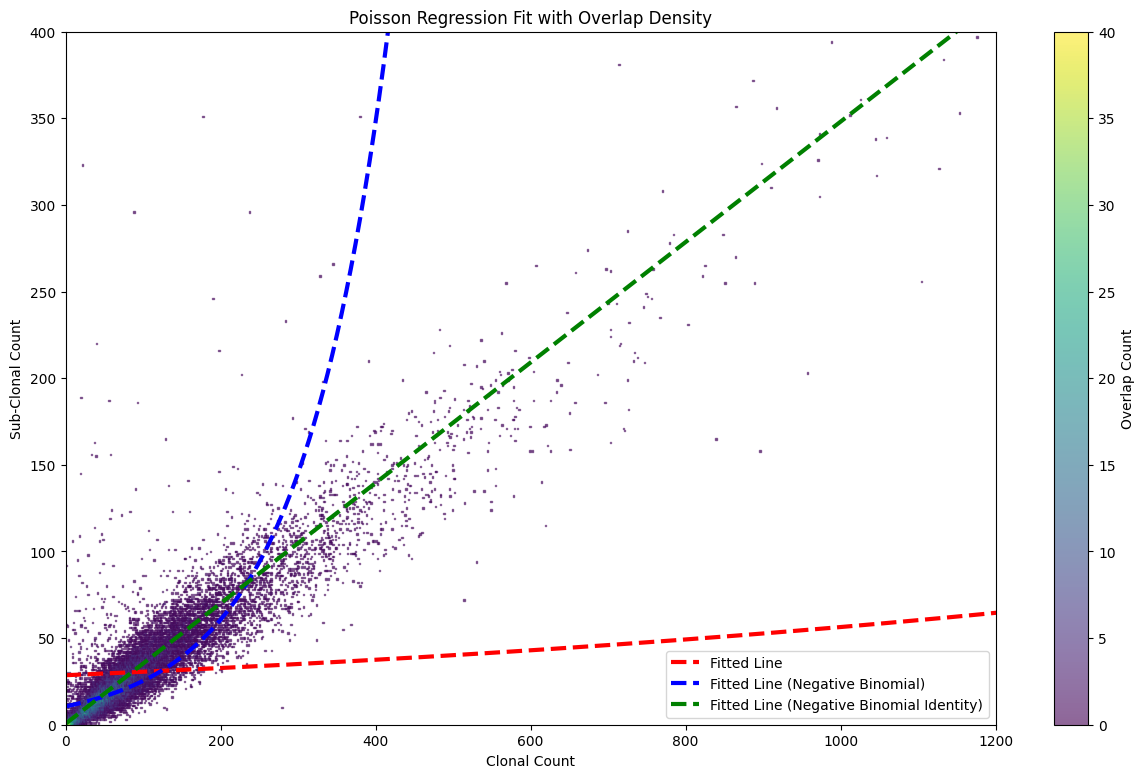

In [4]:
import matplotlib.pyplot as plt

# Prepare the overlap counts for the scatter plot
def add_overlap_counts(summary):
    """Adds overlap count and log(overlap count) columns to the input DataFrame."""
    summary = summary.copy()
    overlap_counts = summary.groupby(['Clonal Count', 'Sub-Clonal Count']).size().reset_index(name='Overlap Count')
    overlap_counts['Log Overlap Count'] = np.log(overlap_counts['Overlap Count'])
    return overlap_counts 

# Calculate predictions
predictions_poisson = poisson_model.predict(x_with_const)
predictions_negbin0 = negbin_model0.predict(x_with_const)
predictions_negbin1 = negbin_model1.predict(x_with_const)

# Sort the x values for consistent plotting
x_sorted = x.argsort()
overlap_counts = add_overlap_counts(clonal_summary_binom)

# Create scatter plot with color mapping
plt.figure(figsize=(15, 9))
plt.xlim(0, 1200)
plt.ylim(0, 400)
scatter = plt.scatter(overlap_counts['Clonal Count'], 
                     overlap_counts['Sub-Clonal Count'],
                     c=overlap_counts['Overlap Count'],  
                     cmap='viridis',
                     vmin=0,
                     vmax=40,                        
                     s=1,                                  
                     marker='s',                           
                     alpha=0.6)                            
# Add colorbar
plt.colorbar(scatter, label='Overlap Count')
# Add fitted line for Poisson regression
plt.plot(x[x_sorted], predictions_poisson[x_sorted], 
         color='red', 
         label='Fitted Line', 
         linestyle='--',
         linewidth=3)
# Add fitted line for Negative Binomial regression
plt.plot(x[x_sorted], predictions_negbin0[x_sorted], 
         color='blue', 
         label='Fitted Line (Negative Binomial)', 
         linestyle='--',
         linewidth=3)
# Add fitted line for Negative Binomial regression with identity link
plt.plot(x[x_sorted], predictions_negbin1[x_sorted], 
         color='green', 
         label='Fitted Line (Negative Binomial Identity)', 
         linestyle='--',
         linewidth=3)

# Customize plot
plt.xlabel('Clonal Count')
plt.ylabel('Sub-Clonal Count')
plt.title('Poisson Regression Fit with Overlap Density')
plt.legend()
plt.show()

In [5]:
from scipy.stats import nbinom, poisson


def negbin_quantiles(Y_pred: pd.Series, scale: float ,q_range=0.95):
    """
    Compute (1 - alpha)% quantile interval of a negative binomial 
    given predicted means (mu) and dispersion alpha.

    Parameters:
    - Y_pred: pd.Series of predicted means (μ values)
    - scale: dispersion parameter (1/theta), where Var(Y) = μ + μ²/theta
    - alpha: float, defines the range for quantiles (default is 0.05 for 95% CI)

    Returns:
    - pd.DataFrame with lower and upper quantiles
    """
    theta = 1 / scale  # Dispersion parameter for Negative Binomial
    alpha = 1 - q_range  # Convert to alpha for quantiles
    p = theta / (theta + Y_pred)
    lower = nbinom.ppf(alpha / 2, theta, p)
    upper = nbinom.ppf(1 - alpha / 2, theta, p)
    return lower, upper

def poisson_quantiles(Y_pred: pd.Series, q_range=0.95):
    """
    Compute (1 - alpha)% quantile interval of a Poisson distribution 
    given predicted means (mu).

    Parameters:
    - Y_pred: pd.Series of predicted means (μ values)
    - q_range: float, defines the range for quantiles (default is 0.95 for 95% CI)

    Returns:
    - lower, upper bounds for the confidence interval
    """
    alpha = 1 - q_range  # Convert to alpha for quantiles
    # Use ppf (percent point function) from scipy.stats.poisson
    lower = poisson.ppf(alpha/2, Y_pred)
    upper = poisson.ppf(1 - alpha/2, Y_pred)
    return lower, upper

# Calculate the quantiles for the predicted values
q_range = 0.95
lower, upper = negbin_quantiles(predictions_negbin0, scale = negbin_model0.params['alpha'], q_range=q_range)
lower_poisson, upper_poisson = poisson_quantiles(predictions_poisson, q_range=q_range)
lower_negbin1, upper_negbin1 = negbin_quantiles(predictions_negbin1, scale = alpha, q_range=q_range)

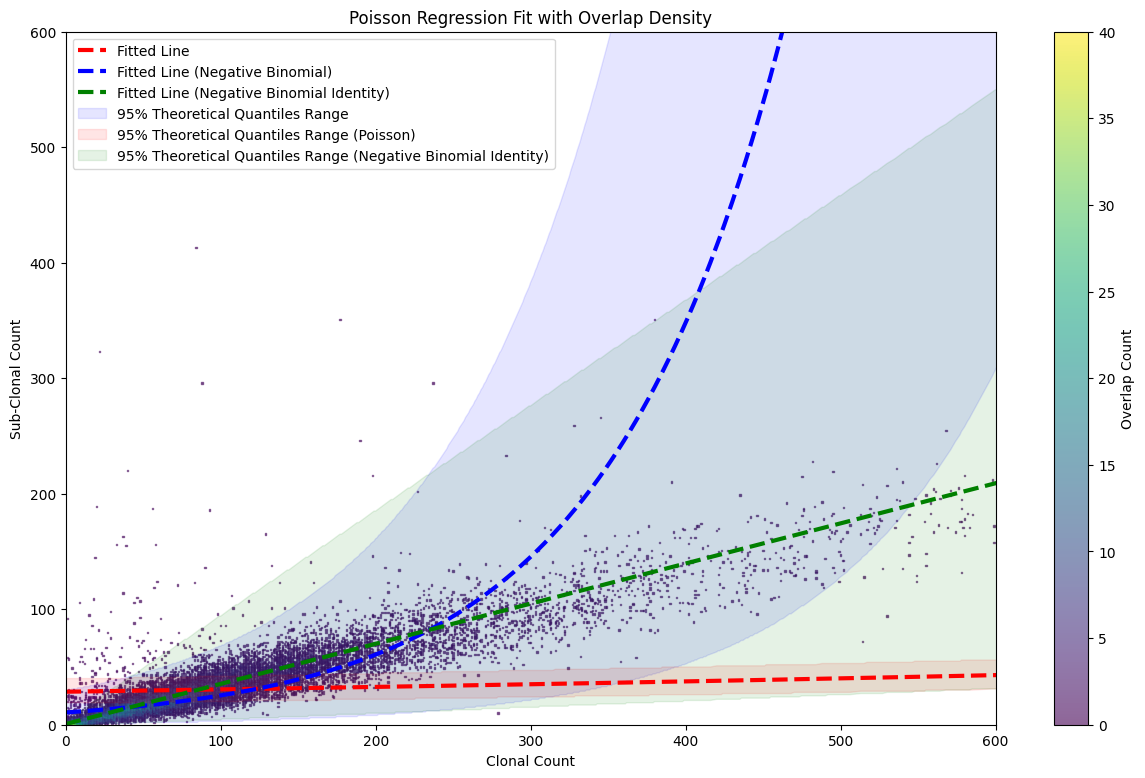

In [6]:
# Create scatter plot with color mapping
plt.figure(figsize=(15, 9))
plt.xlim(0, 600)
plt.ylim(0, 600)
scatter = plt.scatter(overlap_counts['Clonal Count'], 
                     overlap_counts['Sub-Clonal Count'],
                     c=overlap_counts['Overlap Count'],  
                     cmap='viridis',
                     vmin=0,
                     vmax=40,                        
                     s=1,                                  
                     marker='s',                           
                     alpha=0.6)                            
# Add colorbar
plt.colorbar(scatter, label='Overlap Count')
# Add fitted line for Poisson regression
plt.plot(x[x_sorted], predictions_poisson[x_sorted], 
         color='red', 
         label='Fitted Line', 
         linestyle='--',
         linewidth=3)
# Add fitted line for Negative Binomial regression
plt.plot(x[x_sorted], predictions_negbin0[x_sorted], 
         color='blue', 
         label='Fitted Line (Negative Binomial)', 
         linestyle='--',
         linewidth=3)
# Add fitted line for Negative Binomial regression with identity link
plt.plot(x[x_sorted], predictions_negbin1[x_sorted], 
         color='green', 
         label='Fitted Line (Negative Binomial Identity)', 
         linestyle='--',
         linewidth=3)

# Add quantile intervals 
plt.fill_between(x[x_sorted], lower[x_sorted], upper[x_sorted], color="blue", alpha=0.1, label=f"{q_range*100 :.0f}% Theoretical Quantiles Range")
plt.fill_between(x[x_sorted], lower_poisson[x_sorted], upper_poisson[x_sorted], color="red", alpha=0.1, label=f"{q_range*100 :.0f}% Theoretical Quantiles Range (Poisson)")
plt.fill_between(x[x_sorted], lower_negbin1[x_sorted], upper_negbin1[x_sorted], color="green", alpha=0.1, label=f"{q_range*100 :.0f}% Theoretical Quantiles Range (Negative Binomial Identity)")

# Customize plot
plt.xlabel('Clonal Count')
plt.ylabel('Sub-Clonal Count')
plt.title('Poisson Regression Fit with Overlap Density')
plt.legend()
plt.show()

# Model Buiding and target import 

In [7]:
# Import the CGC data and compare with mc3
tsv_data = pd.read_csv("data/cgc.tsv", sep="\t")
tsv_hugo = tsv_data['Gene Symbol'].str.strip().tolist()
mc3_hugo = clonal_summary_binom['Hugo_Symbol'].str.strip().tolist()
diff1 = pd.DataFrame(set(mc3_hugo) - set(tsv_hugo))
diff2 = pd.DataFrame(set(tsv_hugo) - set(mc3_hugo))
intersection = pd.DataFrame(set(mc3_hugo) & set(tsv_hugo))
print("Number of unique Hugo symbols in mc3:", len(set(mc3_hugo)))
print("Number of unique Hugo symbols in tsv:", len(set(tsv_hugo)))
print("Number of unique Hugo symbols in mc3 not in tsv:", len(diff1))
print("Number of unique Hugo symbols in tsv not in mc3:", len(diff2))
print("Number of unique Hugo symbols in both:", len(intersection))

Number of unique Hugo symbols in mc3: 21254
Number of unique Hugo symbols in tsv: 738
Number of unique Hugo symbols in mc3 not in tsv: 20544
Number of unique Hugo symbols in tsv not in mc3: 28
Number of unique Hugo symbols in both: 710


In [8]:
# Add a new column to clonal summary dataframe
clonal_summary_binom['Cancer Gene'] = clonal_summary_binom['Hugo_Symbol'].isin(tsv_hugo)
clonal_summary_Ztest['Cancer Gene'] = clonal_summary_Ztest['Hugo_Symbol'].isin(tsv_hugo)

**The dataset is imbalanced with ~97% false and ~3% true**

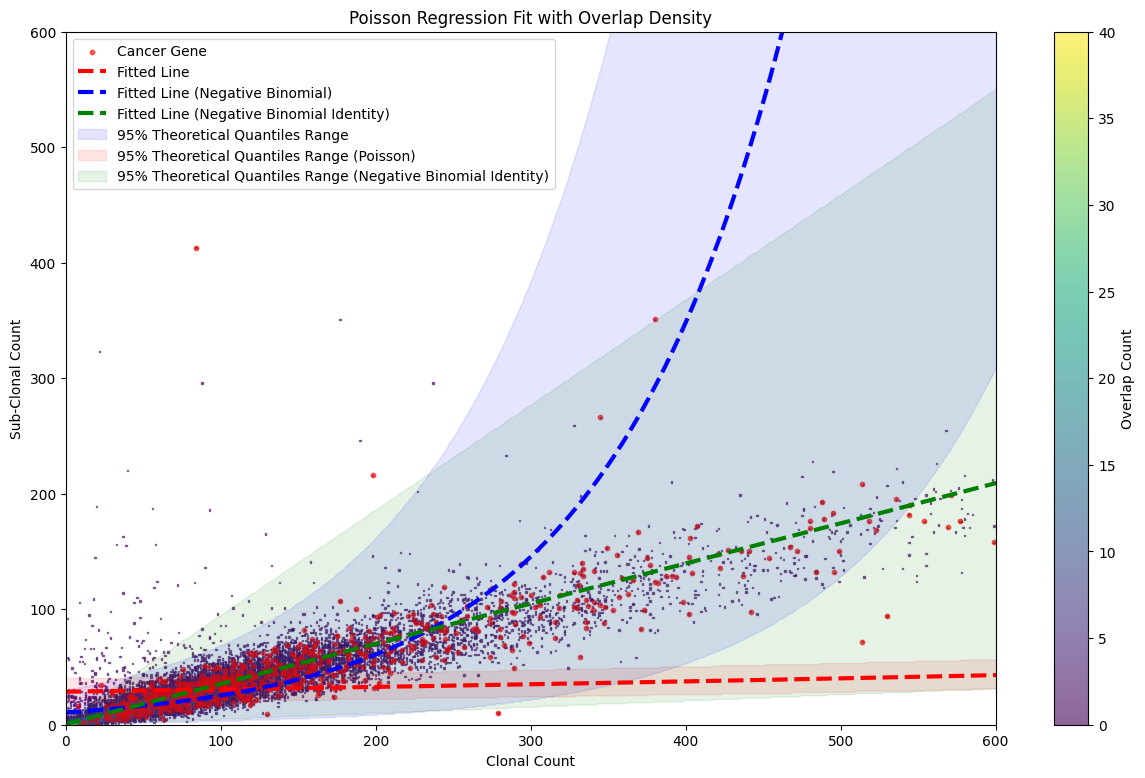

In [9]:
# Create scatter plot with color mapping
plt.figure(figsize=(15, 9))
plt.xlim(0, 600)
plt.ylim(0, 600)
scatter = plt.scatter(overlap_counts['Clonal Count'], 
                     overlap_counts['Sub-Clonal Count'],
                     c=overlap_counts['Overlap Count'],  
                     cmap='viridis',
                     vmin=0,
                     vmax=40,                        
                     s=1,                                  
                     marker='s',                           
                     alpha=0.6)

# Hightlight cancer genes
plt.scatter(clonal_summary_binom[clonal_summary_binom['Cancer Gene']]['Clonal Count'], 
            clonal_summary_binom[clonal_summary_binom['Cancer Gene']]['Sub-Clonal Count'],
            c='red', s=10, label='Cancer Gene', alpha=0.6)

# Add colorbar
plt.colorbar(scatter, label='Overlap Count')
# Add fitted line for Poisson regression
plt.plot(x[x_sorted], predictions_poisson[x_sorted], 
         color='red', 
         label='Fitted Line', 
         linestyle='--',
         linewidth=3)
# Add fitted line for Negative Binomial regression
plt.plot(x[x_sorted], predictions_negbin0[x_sorted], 
         color='blue', 
         label='Fitted Line (Negative Binomial)', 
         linestyle='--',
         linewidth=3)
# Add fitted line for Negative Binomial regression with identity link
plt.plot(x[x_sorted], predictions_negbin1[x_sorted], 
         color='green', 
         label='Fitted Line (Negative Binomial Identity)', 
         linestyle='--',
         linewidth=3)

# Add quantile intervals 
plt.fill_between(x[x_sorted], lower[x_sorted], upper[x_sorted], color="blue", alpha=0.1, label=f"{q_range*100 :.0f}% Theoretical Quantiles Range")
plt.fill_between(x[x_sorted], lower_poisson[x_sorted], upper_poisson[x_sorted], color="red", alpha=0.1, label=f"{q_range*100 :.0f}% Theoretical Quantiles Range (Poisson)")
plt.fill_between(x[x_sorted], lower_negbin1[x_sorted], upper_negbin1[x_sorted], color="green", alpha=0.1, label=f"{q_range*100 :.0f}% Theoretical Quantiles Range (Negative Binomial Identity)")

# Customize plot
plt.xlabel('Clonal Count')
plt.ylabel('Sub-Clonal Count')
plt.title('Poisson Regression Fit with Overlap Density')
plt.legend()
plt.show()

# Testing for Overdispersion in the Negative Binomial Model
Verify if the negative binomial model properly accounts for overdispersion using multiple methods.

In [ ]:
# Method 1: Inspect the Dispersion Parameter
print("Method 1: Dispersion Parameter Analysis")
print(f"Dispersion parameter (alpha): {alpha}")
print(f"Is overdispersion significant? {'Yes' if alpha > 0.05 else 'No'}")

# Method 2: Compare Observed vs. Predicted Variance using Pearson Chi-Square
residuals_pearson = negbin_model0.resid_pearson
chi2 = np.sum(residuals_pearson**2)
df = negbin_model0.df_resid
overdispersion_ratio = chi2 / df

print("\nMethod 2: Pearson Chi-Square Analysis")
print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {df}")
print(f"Overdispersion ratio (Chi2/df): {overdispersion_ratio:.2f}")
print(f"Model fit assessment: {'Potential overdispersion' if overdispersion_ratio > 1.5 else 'Good fit'}")

# Method 3: Likelihood Ratio Test (NB vs. Poisson)
lr_stat = -2 * (poisson_model.llf - negbin_model0.llf)
from scipy.stats import chi2  # Use scipy's chi2 distribution
p_value = chi2.sf(lr_stat, df=1)

print("\nMethod 3: Likelihood Ratio Test (NB vs. Poisson)")
print(f"LR statistic: {lr_stat:.2f}")
print(f"p-value: {p_value:.2e}")
print(f"Result: {'NB model preferred' if p_value < 0.05 else 'Poisson model sufficient'}")

In [ ]:
# Visual Check: Observed vs. Predicted Variance
predicted = negbin_model1.predict()
n_bins = 10

# Create bins based on predicted values
bins = pd.qcut(predicted, n_bins, duplicates='drop')

# Calculate observed and predicted variances within bins
observed_var = y.groupby(bins).var()
# Convert predicted numpy array to pandas Series
predicted_series = pd.Series(predicted)
predicted_mean = predicted_series.groupby(bins).mean()
predicted_var = predicted_mean + alpha * predicted_mean**2

# Convert to DataFrames for easier plotting
var_df = pd.DataFrame({
    'Predicted Variance': predicted_var,
    'Observed Variance': observed_var
})

# Plot
plt.figure(figsize=(5, 4))
plt.scatter(var_df['Predicted Variance'], var_df['Observed Variance'], 
           alpha=0.6, label='Observed vs. Predicted')
max_val = max(var_df['Predicted Variance'].max(), var_df['Observed Variance'].max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Ideal Fit')

plt.xlabel('Predicted Variance (NB)')
plt.ylabel('Observed Variance')
plt.title('Negative Binomial Model: Variance Check')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print variance comparison
print("\nBin-wise Variance Comparison:")
print(var_df)

# Residual analysis

In [14]:
# --- Calculate residuals ---
# 1. Calculate residuals
predicted_counts = negbin_model0.predict(x_with_const)
raw_residuals = y - predicted_counts

# 2. Pearson Residuals (already available)
pearson_residuals = negbin_model0.resid_pearson

# 3. Calculate deviance residuals manually
alpha = negbin_model0.params['alpha']
mu = predicted_counts
y_obs = y

# Manual calculation of deviance residuals
import numpy as np
# Handle zeros in log calculations
y_obs_safe = np.maximum(y_obs, 1e-10)
mu_safe = np.maximum(mu, 1e-10)
deviance_residuals = np.sign(y_obs - mu) * np.sqrt(2 * (
    y_obs * np.log(y_obs_safe / mu_safe) - 
    (y_obs + 1/alpha) * np.log((y_obs + 1/alpha) / (mu + 1/alpha))
))
# Handle NaN values that might arise
deviance_residuals = np.nan_to_num(deviance_residuals)

# Combine into a DataFrame for inspection
residuals_df = pd.DataFrame({
    "Hugo": clonal_summary_binom["Hugo_Symbol"],
    "Observed": y,
    "Predicted": predicted_counts,
    "Raw_Residual": raw_residuals,
    "Deviance_Residual": deviance_residuals,
    "Pearson_Residual": pearson_residuals
}, index=clonal_summary_binom.index)

# Sort by absolute deviance residuals (top outliers first)
outlier_candidates = residuals_df.sort_values(
    by="Deviance_Residual", 
    key=lambda x: np.abs(x), 
    ascending=False
)

# Display top 10 potential outliers
print(outlier_candidates.head(10))

          Hugo  Observed     Predicted  Raw_Residual  Deviance_Residual  \
18939      TTN      3054  1.197418e+34 -1.197418e+34         -18.119597   
11021    MUC16      1410  3.745914e+15 -3.745914e+15         -11.424691   
12734  PDE4DIP       759  3.098724e+01  7.280128e+02           9.596364   
11251    NBPF1       323  1.282679e+01  3.101732e+02           9.490640   
18394     TP53       142  9.702397e+09 -9.702397e+09          -8.973456   
1713    BCLAF1       413  2.204280e+01  3.909572e+02           8.126046   
9615     LRP1B       665  6.071666e+07 -6.071599e+07          -7.018922   
11709    NPY4R       189  1.260470e+01  1.763953e+02           6.944579   
13615    PRIM2       220  1.501022e+01  2.049898e+02           6.898952   
17382    SYNE1       627  1.624078e+07 -1.624015e+07          -6.580917   

       Pearson_Residual  
18939         -1.537510  
11021         -1.537510  
12734         34.818479  
11251         34.164401  
18394         -1.537510  
1713          25.9

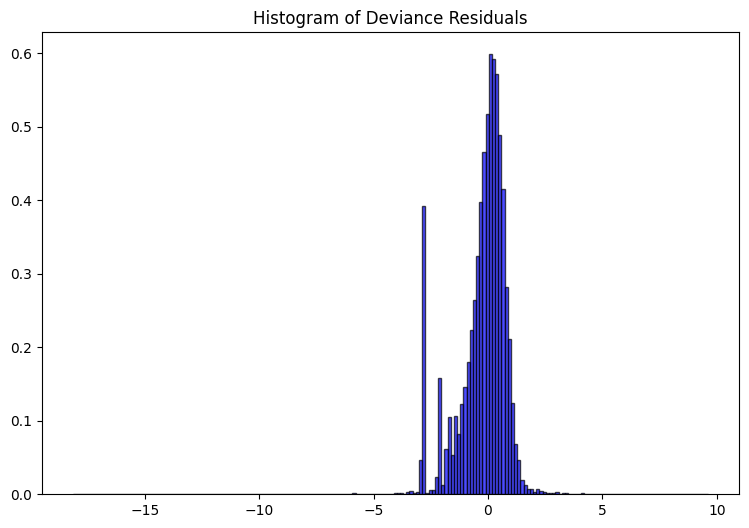

In [23]:
plt.figure(figsize=(9, 6))
plt.hist(residuals_df['Deviance_Residual'], bins=200, alpha=0.7, color='blue', edgecolor='black', density=True)
plt.title('Histogram of Deviance Residuals')
plt.show()

In [ ]:
clonal_summary_binom['Deviance Residual'] = deviance_residuals
clonal_summary_binom['Pred Cancer Gene'] = clonal_summary_binom.apply(
    lambda row: True if abs(row['Deviance Residual']) > 2 else False, axis=1
)

# ROC Curve Analysis for Cancer Gene Prediction
Let's evaluate how well the absolute deviance residuals can predict cancer genes at different thresholds.

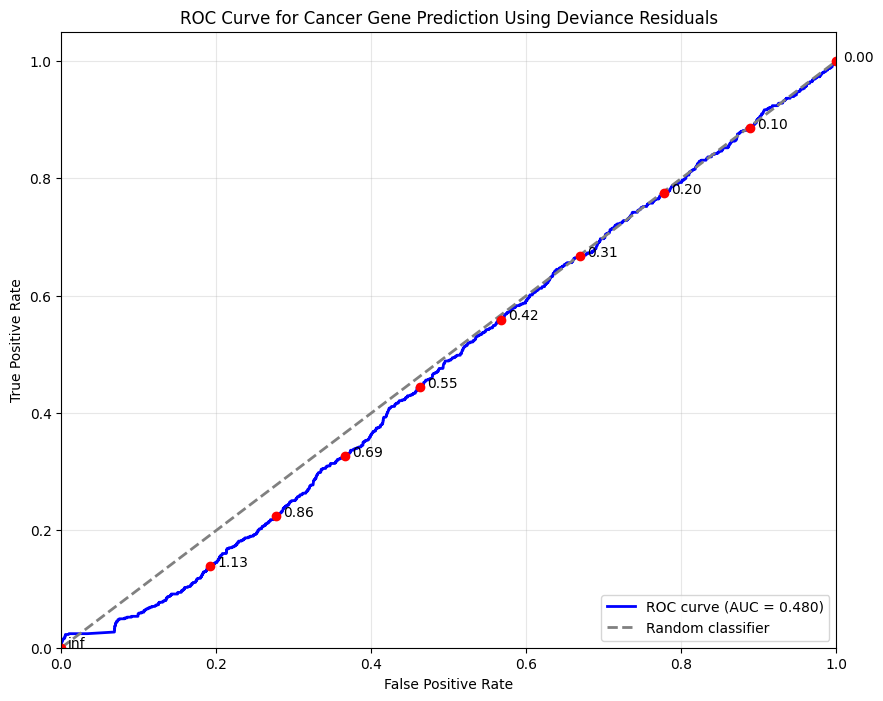

In [28]:
# ROC curve for Cancer Gene prediction based on deviance residuals
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

# Get absolute deviance residuals as our prediction scores
abs_residuals = np.abs(clonal_summary_binom['Deviance Residual'])

# Get true labels (actual cancer genes)
true_labels = clonal_summary_binom['Cancer Gene']

# Calculate ROC curve points
fpr, tpr, thresholds = roc_curve(true_labels, abs_residuals)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='blue', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Cancer Gene Prediction Using Deviance Residuals')
plt.legend(loc="lower right")

# Add threshold labels for some key points
marker_indices = np.linspace(0, len(thresholds)-1, 10).astype(int)
for idx in marker_indices:
    plt.plot(fpr[idx], tpr[idx], 'ro')
    plt.annotate(f"{thresholds[idx]:.2f}", 
                 (fpr[idx], tpr[idx]),
                 textcoords="offset points",
                 xytext=(5, 0),
                 ha='left')

plt.grid(alpha=0.3)
plt.show()